In [51]:
import pandas as pd
import numpy as np
from typing import List, Tuple
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score

In [52]:
BASE_PATH = './data'

In [53]:
targets = pd.read_csv(f'{BASE_PATH}/train.csv')
A = pd.read_csv(f'{BASE_PATH}/train/A.csv')
B = pd.read_csv(f'{BASE_PATH}/train/B.csv')

In [54]:
A_target = targets[targets['Test']=='A']
B_target = targets[targets['Test']=='B']

In [55]:
A_train = pd.merge(A, A_target, on = 'Test_id', how = 'left')
B_train = pd.merge(B, B_target, on = 'Test_id', how = 'left')

In [56]:
A_train

,Test_id,Test_x,PrimaryKey,Age,TestDate,A1-1,A1-2,A1-3,A1-4,A2-1,...,A7-1,A8-1,A8-2,A9-1,A9-2,A9-3,A9-4,A9-5,Test_y,Label
0,0x744773A3B58E27F1811B47B53331F272AB5E569A9F72...,A,0x744773A3B58E27F1811B47B53331F272AB5E569A9F72...,20a,201811,"2,2,1,2,1,2,1,1,2,1,2,1,1,2,1,2,2,1","1,3,3,2,3,3,2,2,3,3,2,1,2,1,1,1,2,1","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0","29,33,56,64,5,-51,44,-1,0,31,30,5,67,33,43,21,...","1,1,2,3,1,2,2,3,3,1,1,3,2,2,1,2,3,3",...,15,0,1,4,16,0,5,7,A,0
1,0xDA7DE599194F2B4F9624ACBCE96E66E2F8B357A4DD97...,A,0xDA7DE599194F2B4F9624ACBCE96E66E2F8B357A4DD97...,20a,201811,"2,2,1,2,2,1,1,1,2,2,1,2,1,1,2,1,2,1","3,2,2,1,1,3,1,1,2,3,2,1,3,1,2,3,3,2","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0","76,1,27,25,41,34,-24,7,18,85,-18,-21,31,-7,18,...","2,3,3,1,2,2,3,2,3,1,2,3,1,3,2,1,1,1",...,11,9,0,1,3,0,0,4,A,0
2,0x7DF700D37380AD164ADF79B485C3A84A571186E3DB27...,A,0x7DF700D37380AD164ADF79B485C3A84A571186E3DB27...,20a,201802,"1,1,2,1,2,2,2,2,1,2,1,1,1,1,1,2,2,2","2,3,3,1,1,2,1,1,3,2,1,2,2,3,1,2,3,3","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0","-1,22,0,-37,-21,7,-34,-21,-79,-26,-80,-23,-63,...","1,1,3,2,3,2,1,1,1,1,3,2,2,2,2,3,3,3",...,16,2,2,2,5,0,4,4,A,0
3,0xAB057D1B8C3A8FB6E99F1B6E0F95086150951BCA8630...,A,0xAB057D1B8C3A8FB6E99F1B6E0F95086150951BCA8630...,20a,201805,"2,2,2,2,1,2,1,1,2,2,1,1,1,1,2,1,2,1","1,3,3,1,2,2,2,3,2,3,2,1,1,1,2,3,1,3","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0","-60,25,-25,-34,-40,-60,-46,-79,-77,-51,-80,-62...","1,2,2,3,1,1,2,2,3,1,3,2,1,3,3,3,2,1",...,15,0,0,0,0,2,0,2,A,0
4,0xAD4EC2C13080BC51C988805376AB404CCD2BA53CB108...,A,0xAD4EC2C13080BC51C988805376AB404CCD2BA53CB108...,20a,201806,"2,2,1,1,2,1,1,2,1,1,1,1,2,2,1,2,2,2","1,3,1,3,2,1,1,1,3,2,2,2,2,3,3,3,2,1","0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0","-42,-77,-33,-3,-38,-58,-88,-4,-28,-58,-40,-29,...","1,3,3,2,2,2,3,1,3,1,1,2,1,3,1,2,3,2",...,8,0,2,9,16,1,21,4,A,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
647236,0x5CC9861BC48C709E0B363F8568B5DBDC335876A36F0B...,A,0x5CC9861BC48C709E0B363F8568B5DBDC335876A36F0B...,70b,202205,"2,2,1,1,1,2,1,1,1,2,1,1,2,2,2,2,1,2","3,2,1,2,3,2,3,1,2,1,2,1,2,1,3,3,3,1","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0","-17,-151,-54,-6,124,-83,56,-7,10,-21,61,1,-43,...","1,2,1,3,1,3,1,3,1,2,2,2,3,3,3,2,2,1",...,7,4,3,11,10,0,13,11,A,0
647237,0x10F17BF0CABB791E9AC441B9F5E4C8A6126E295125AA...,A,0x10F17BF0CABB791E9AC441B9F5E4C8A6126E295125AA...,70b,202209,"2,1,2,1,2,1,2,2,2,2,1,1,1,1,1,1,2,2","1,1,3,2,1,2,2,2,3,2,3,1,2,1,3,3,1,3","0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0","-77,5,-213,-97,-72,-97,-89,-197,-111,-146,-344...","3,3,3,2,3,1,2,2,1,2,3,1,2,1,1,1,2,3",...,2,6,4,34,14,16,33,18,A,0
647238,0x97471D5B563350E9ED0637C7DD18C4EB72F7EE3A6AF6...,A,0x97471D5B563350E9ED0637C7DD18C4EB72F7EE3A6AF6...,70b,202203,"2,1,2,1,1,2,2,1,2,1,1,1,1,2,2,2,2,1","2,1,3,3,2,3,2,3,1,1,1,2,2,3,2,1,1,3","1,1,1,0,1,0,1,1,0,1,1,0,0,0,0,0,1,0","639,-481,725,-233,-342,-256,-322,-848,-294,-33...","1,1,2,1,3,1,3,1,2,3,3,2,2,3,1,3,2,2",...,1,8,3,27,20,13,25,18,A,0
647239,0xF43480648818B07D8FA3C12CC364CA35AA777417E17C...,A,0xF43480648818B07D8FA3C12CC364CA35AA777417E17C...,70b,202205,"1,1,2,2,1,2,2,1,1,2,2,1,2,1,1,2,1,2","1,3,3,2,1,3,1,2,2,3,1,3,2,2,3,1,1,2","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0","-28,-3,-42,-3,-24,8,-8,-18,-6,-77,8,-54,35,44,...","2,2,3,1,3,3,2,3,1,1,3,1,1,3,2,2,2,1",...,6,9,2,8,4,3,1,8,A,0


In [57]:
A_numeric_cols = ['A1-4','A2-4','A3-7','A4-5']
B_numeric_cols = ['B1-2','B2-2','B3-2','B4-2','B5-2']

In [58]:
A_int_cols = ['A8-1','A8-2','A9-1','A9-2','A9-3','A9-4','A9-5']
B_int_cols = ['B9-1','B9-2','B9-3','B9-4','B9-5','B10-1','B10-2','B10-3','B10-4','B10-5','B10-6']

In [59]:
for col in A_int_cols:
    A_train[col] = A_train[col].astype('int')

for col in B_int_cols:
    B_train[col] = B_train[col].astype('category')

In [60]:
def feature_add_rp_time(df, cols):
    for col in cols:
        df[f'{col}_mean'] = df[col].apply(
            lambda x: sum(map(float, x.split(','))) / len(x.split(',')) 
            if isinstance(x, str) else x
        )
    return df

In [61]:
A_train = A_train.dropna()
B_train = B_train.dropna()

In [62]:
A_train = feature_add_rp_time(A_train,A_numeric_cols)
B_train = feature_add_rp_time(B_train,B_numeric_cols)

/tmp/ipykernel_963703/2805808153.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[f'{col}_mean'] = df[col].apply(
/tmp/ipykernel_963703/2805808153.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[f'{col}_mean'] = df[col].apply(
/tmp/ipykernel_963703/2805808153.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/u

In [63]:
A_str_cols = A_train.select_dtypes(include='object').columns.tolist()
B_str_cols = B_train.select_dtypes(include='object').columns.tolist()

for col in A_str_cols:
    A_train[col] = A_train[col].astype('category')

for col in B_str_cols:
    B_train[col] = B_train[col].astype('category')

print(A_train.dtypes)
print(B_train.dtypes)

/tmp/ipykernel_963703/4259070361.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  A_train[col] = A_train[col].astype('category')
/tmp/ipykernel_963703/4259070361.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  A_train[col] = A_train[col].astype('category')
/tmp/ipykernel_963703/4259070361.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.

Test_id       category
Test_x        category
PrimaryKey    category
Age           category
TestDate         int64
A1-1          category
A1-2          category
A1-3          category
A1-4          category
A2-1          category
A2-2          category
A2-3          category
A2-4          category
A3-1          category
A3-2          category
A3-3          category
A3-4          category
A3-5          category
A3-6          category
A3-7          category
A4-1          category
A4-2          category
A4-3          category
A4-4          category
A4-5          category
A5-1          category
A5-2          category
A5-3          category
A6-1             int64
A7-1             int64
A8-1             int64
A8-2             int64
A9-1             int64
A9-2             int64
A9-3             int64
A9-4             int64
A9-5             int64
Test_y        category
Label            int64
A1-4_mean      float64
A2-4_mean      float64
A3-7_mean      float64
A4-5_mean      float64
dtype: obje

In [64]:
drops = ['Test_id','Test_x','Test_y','Label']

In [65]:
def convert_age(val):
    if pd.isna(val):
        return np.nan
    val = str(val)
    if val.endswith('a'):
        return int(val[:-1]) + 3
    elif val.endswith('b'):
        return int(val[:-1]) + 7
    else:
        return float(val)
    
A_train['Age'] = A_train['Age'].apply(convert_age)

/tmp/ipykernel_963703/1404005066.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  A_train['Age'] = A_train['Age'].apply(convert_age)


In [66]:
A_X = A_train.drop(columns=drops)
A_Y = A_train['Label']
B_X = B_train.drop(columns=drops)
B_Y = B_train['Label']

In [67]:
xa_train, xa_val, ya_train, ya_val = train_test_split(A_X, A_Y, test_size=0.2, random_state=42)
xb_train, xb_val, yb_train, yb_val = train_test_split(B_X, B_Y, test_size=0.2, random_state=42)

xa_train, xa_test, ya_train, ya_test = train_test_split(xa_train, ya_train, test_size=0.2, random_state=42)
xb_train, xb_test, yb_train, yb_test = train_test_split(xb_train, yb_train, test_size=0.2, random_state=42)

In [68]:
A_cats = A_X.select_dtypes(include='category').columns.tolist()
B_cats = B_X.select_dtypes(include='category').columns.tolist()

In [69]:
A_train_pool = Pool(
    data=xa_train,
    label=ya_train,
    cat_features=A_cats
)

A_val_pool = Pool(
    data=xa_val,
    label=ya_val,
    cat_features=A_cats
)

B_train_pool = Pool(
    data=xb_train,
    label=yb_train,
    cat_features=B_cats
)

B_val_pool = Pool(
    data=xb_val,
    label=yb_val,
    cat_features=B_cats
)


In [70]:
from sklearn.metrics import roc_auc_score, brier_score_loss
import numpy as np

def expected_calibration_error(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    binids = np.digitize(y_prob, bins) - 1
    ece = 0.0
    for i in range(n_bins):
        bin_true = y_true[binids == i]
        bin_prob = y_prob[binids == i]
        if len(bin_true) > 0:
            acc = bin_true.mean()
            conf = bin_prob.mean()
            ece += np.abs(acc - conf) * len(bin_true) / len(y_true)
    return ece


def leaderboard_metric(y_true, y_pred):
    auc = roc_auc_score(y_true, y_pred)
    brier = brier_score_loss(y_true, y_pred)
    ece = expected_calibration_error(y_true, y_pred)
    
    score = 0.5 * (1 - auc) + 0.25 * brier + 0.25 * ece
    
    return 'leaderboard_score', score, False

In [71]:
class Leaderboard_metric():
    def get_final_error(self, error, weight):
        return error

    def is_max_optimal(self):
        return False
    
    def evaluate(self, approxes, targets, weight):
        logits = np.array(approxes[0])
        probs = 1 / (1 + np.exp(-logits))

        try:
            auc = roc_auc_score(targets, probs)
        except ValueError:
            auc = 0.5
        
        brier = np.mean((probs - targets) ** 2)

        ece = expected_calibration_error(np.array(targets), probs)

        score = 0.5 * (1 - auc) + 0.25 * brier + 0.25 * ece

        return score, len(targets)

In [72]:
A_model = CatBoostClassifier(
    iterations=500,           # n_estimators에 해당
    learning_rate=0.05,
    depth=5,                  # max_depth에 해당
    subsample=0.8,
    colsample_bylevel=0.8,    # colsample_bytree 유사 파라미터
    random_seed=42,
    eval_metric=Leaderboard_metric(),        # 또는 'Accuracy', 'F1' 등 선택 가능
    verbose=100,              # 100 step마다 로그 출력
    task_type="CPU"           # GPU 사용 시 "GPU"로 변경
)

B_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=5,
    subsample=0.8,
    colsample_bylevel=0.8,
    random_seed=42,
    eval_metric=Leaderboard_metric(),        # 또는 'Accuracy', 'F1' 등 선택 가능
    verbose=100,
    task_type="CPU"
)

In [74]:
A_model.fit(
    A_train_pool,
    eval_set=A_val_pool,
    use_best_model=True
)

B_model.fit(
    B_train_pool,
    eval_set=B_val_pool,
    use_best_model=True
)

/opt/conda/envs/ark_v2/lib/python3.11/site-packages/catboost/core.py:2321: UserWarning: Failed to import numba for optimizing custom metrics and objectives
  _check_train_params(params)


0:	learn: 0.3768154	test: 0.3839207	best: 0.3839207 (0)	total: 609ms	remaining: 5m 3s
100:	learn: 0.1559111	test: 0.1613007	best: 0.1612960 (98)	total: 1m 4s	remaining: 4m 16s
200:	learn: 0.1508685	test: 0.1588879	best: 0.1588879 (200)	total: 2m 13s	remaining: 3m 18s
300:	learn: 0.1485210	test: 0.1580125	best: 0.1580125 (300)	total: 3m 20s	remaining: 2m 12s
400:	learn: 0.1469535	test: 0.1575958	best: 0.1575958 (400)	total: 4m 23s	remaining: 1m 4s
499:	learn: 0.1452370	test: 0.1571695	best: 0.1571591 (496)	total: 5m 26s	remaining: 0us

bestTest = 0.1571591246
bestIteration = 496

Shrink model to first 497 iterations.


/opt/conda/envs/ark_v2/lib/python3.11/site-packages/catboost/core.py:2321: UserWarning: Failed to import numba for optimizing custom metrics and objectives
  _check_train_params(params)


0:	learn: 0.3991523	test: 0.3958759	best: 0.3958759 (0)	total: 200ms	remaining: 1m 39s
100:	learn: 0.1893272	test: 0.1663248	best: 0.1663248 (100)	total: 20s	remaining: 1m 18s
200:	learn: 0.1834960	test: 0.1629874	best: 0.1629498 (190)	total: 41.5s	remaining: 1m 1s
300:	learn: 0.1803053	test: 0.1621041	best: 0.1620026 (285)	total: 1m 2s	remaining: 41.5s
400:	learn: 0.1774161	test: 0.1612381	best: 0.1612203 (376)	total: 1m 24s	remaining: 20.8s
499:	learn: 0.1746623	test: 0.1608537	best: 0.1607716 (489)	total: 1m 46s	remaining: 0us

bestTest = 0.16077161
bestIteration = 489

Shrink model to first 490 iterations.


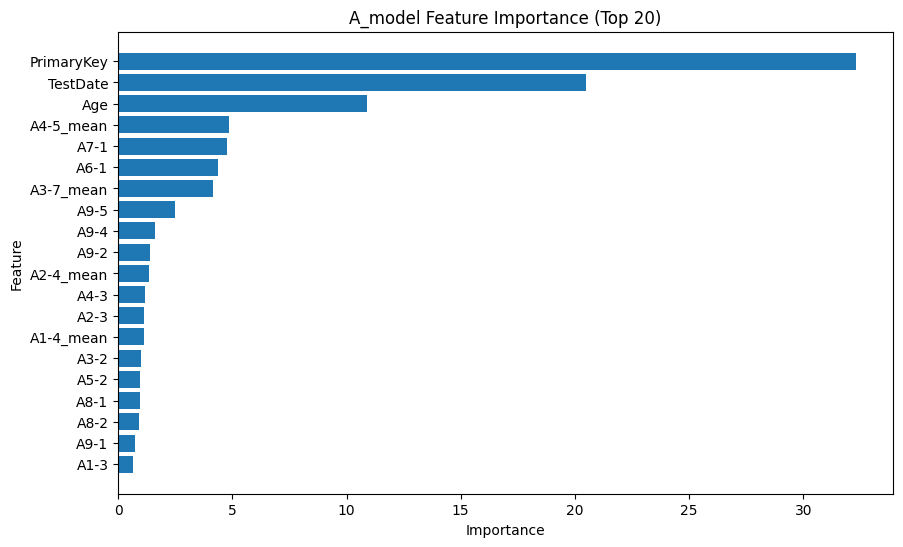

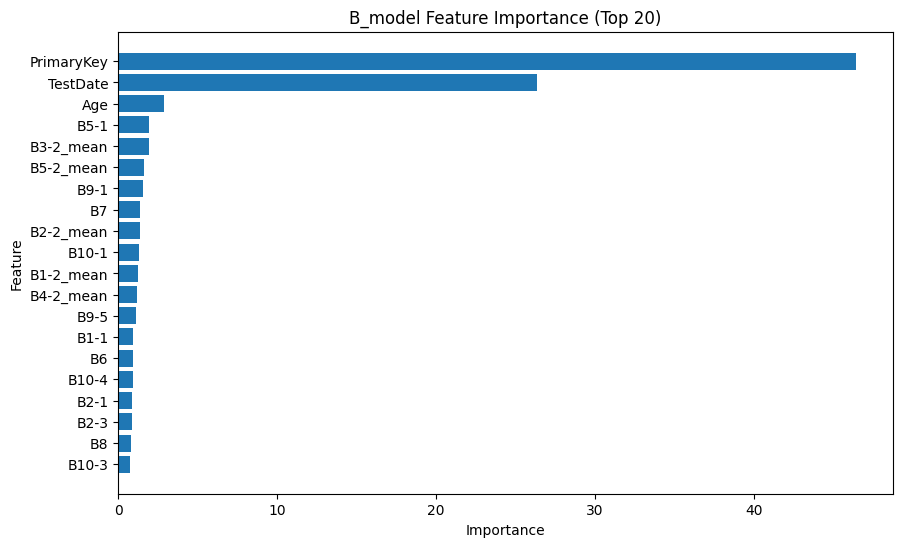

In [75]:
import matplotlib.pyplot as plt
import pandas as pd

# A_model 특성 중요도
A_importances = A_model.get_feature_importance(A_train_pool)
A_features = A_train_pool.get_feature_names()

A_feature_importance = pd.DataFrame({
    "Feature": A_features,
    "Importance": A_importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(A_feature_importance["Feature"][:20][::-1], A_feature_importance["Importance"][:20][::-1])
plt.title("A_model Feature Importance (Top 20)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


# B_model 특성 중요도
B_importances = B_model.get_feature_importance(B_train_pool)
B_features = B_train_pool.get_feature_names()

B_feature_importance = pd.DataFrame({
    "Feature": B_features,
    "Importance": B_importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(B_feature_importance["Feature"][:20][::-1], B_feature_importance["Importance"][:20][::-1])
plt.title("B_model Feature Importance (Top 20)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


In [ ]:
import joblib

joblib.dump(A_model, "./model/A_model.pkl")
joblib.dump(B_model, "./model/B_model.pkl")

['./model/B_model.pkl']